# MIRAGE — Phase 0 (MVP)

**Question** : un world model *simple* (séquence MLP) prédit-il le log-rendement
next-step du mid-price **mieux** que des baselines naïves, **en out-of-sample
honnête** (walk-forward purgé, anti-lookahead) ?

Ce notebook **appelle le harness** (mêmes modules que `python -m mirage.eval`) et
affiche les résultats. Write-up complet : [`../reports/PHASE0.md`](../reports/PHASE0.md).

In [1]:
import os
# exécuter depuis la racine du repo (les chemins du config sont relatifs à la racine)
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
import pandas as pd
from mirage.eval import load_config, run_phase0, go_no_go

cfg = load_config("configs/phase0.yaml")
print("tickers :", [i["ticker"] for i in cfg["data"]["instruments"]])
print("horizon :", cfg["target"]["horizon"], "| barres :", cfg["bars"]["freq"],
      "| baselines :", cfg["baselines"])

tickers : ['AMZN', 'GOOG', 'INTC', 'MSFT', 'AAPL']
horizon : 1 | barres : 1s | baselines : ['zero', 'persistence', 'linear']


## Éval @1 s — world model (MLP) vs baselines

Walk-forward expansif purgé (embargo ≥ horizon), scaler fit sur le train seulement,
métrique pré-enregistrée **R²_OOS** (> 0 ⟺ on bat « prédire 0 »).

In [2]:
res, meta = run_phase0(cfg)
print(meta.to_string(index=False))
piv = res.pivot_table(index="ticker", columns="estimator", values="r2_oos", aggfunc="mean")
piv.round(5)

ticker  n_bars  n_folds  horizon  embargo
  AMZN   23389        5        1       10
  GOOG   23389        5        1       10
  INTC   23389        5        1       10
  MSFT   23389        5        1       10
  AAPL    3589        5        1       10


estimator,linear,mlp,persistence,zero
ticker,,,,
AAPL,-0.01929,-0.10794,-1.00704,0.0
AMZN,0.00293,-0.02918,-0.92323,0.0
GOOG,-0.01682,-0.05152,-0.94659,0.0
INTC,0.01754,-0.02863,-0.99246,0.0
MSFT,0.02435,0.00480,-0.98319,0.0


In [3]:
print(go_no_go(res, cfg["model"]["name"]))


=== Go/No-Go (mlp) ===
  R2_OOS moyen (pooled)  modèle  : -0.042494  (bat zero ? False)
  R2_OOS moyen (pooled)  linéaire: +0.001743  (modèle > linéaire ? False)
  modèle bat zero    sur 1/5 tickers
  modèle bat linéaire sur 0/5 tickers
  --> VERDICT : NO-GO
  (NO-GO = résultat valide et documenté, pas un échec — I3)



## Horizon sweep (pré-calculé) — ce qui est prédictible vs pas

Figures produites par `python -m mirage.sweep` (grid pré-enregistré 1/5/10/30/60 s).

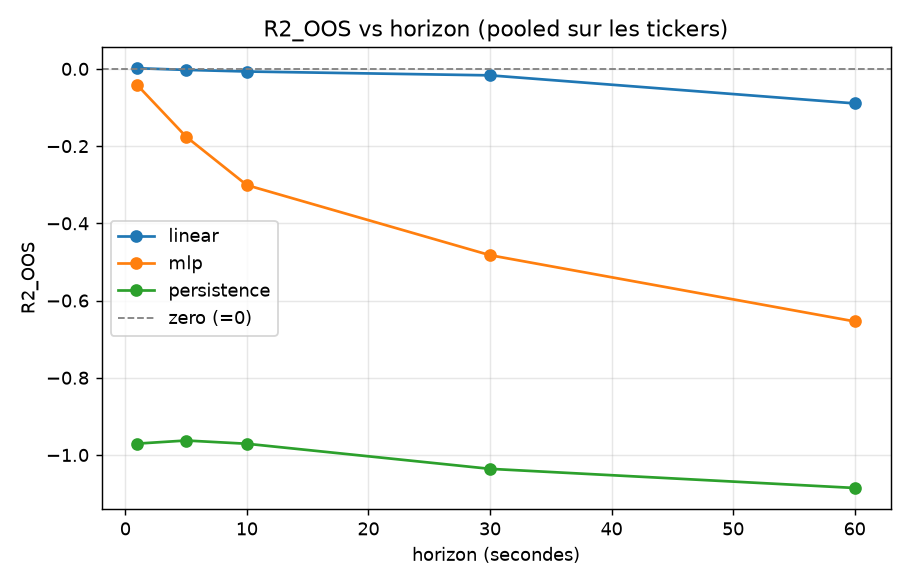

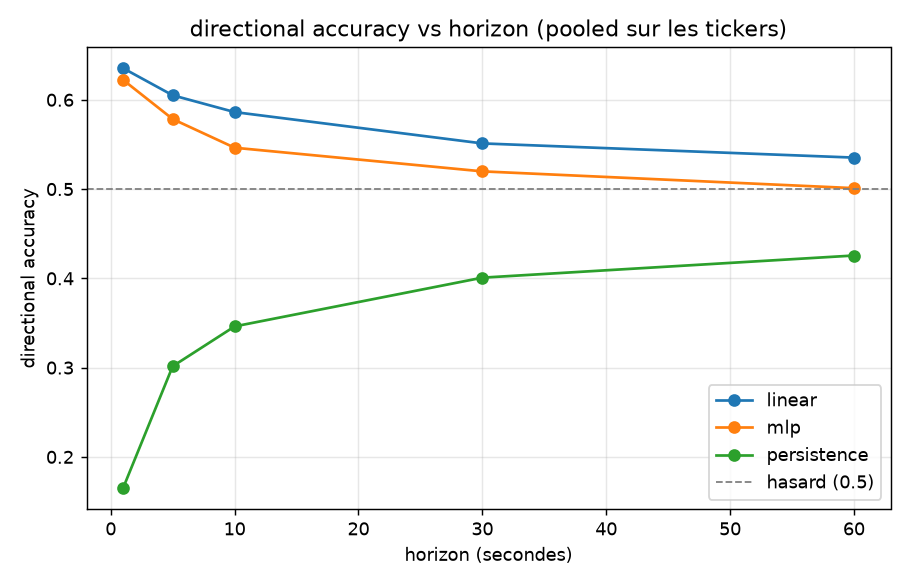

In [4]:
from IPython.display import Image, display
display(Image("reports/figures/horizon_sweep_r2oos.png"))
display(Image("reports/figures/horizon_sweep_diracc.png"))

## Conclusion

**NO-GO** : aucun modèle ne bat le zero-forecast en R²_OOS, à aucun horizon.
Mais le **signe** est prédictible à 1 s, concentré sur les **large-tick** (INTC/MSFT
~80 %) — significatif (block bootstrap) mais **net de coûts négatif** : un *edge
statistique qui est un mirage*. Détail : `scripts/bootstrap_signif.py` et
[`../reports/PHASE0.md`](../reports/PHASE0.md) §4.4.